# # Analyse Exploratoire — Indicateurs Économiques Africains (2010-2023)
# **Auteur :** DOUMBIA  
# **Outil :** Python, Pandas, Seaborn, Matplotlib  
# **Source :** World Bank Open Data (Kaggle)  
# **Date :** Juin 2026

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

#chargement des données
df = pd.read_csv("data.csv")

#Premiers aperçus
print("Dimensions:", df.shape)
print("\nColonnes:", df.columns.tolist())
print("\nAperçu:")
df.head()

Dimensions: (3472, 16)

Colonnes: ['country_name', 'country_id', 'year', 'Inflation (CPI %)', 'GDP (Current USD)', 'GDP per Capita (Current USD)', 'Unemployment Rate (%)', 'Interest Rate (Real, %)', 'Inflation (GDP Deflator, %)', 'GDP Growth (% Annual)', 'Current Account Balance (% GDP)', 'Government Expense (% of GDP)', 'Government Revenue (% of GDP)', 'Tax Revenue (% of GDP)', 'Gross National Income (USD)', 'Public Debt (% of GDP)']

Aperçu:


,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
0,Aruba,aw,2010,2.078141,2.453597e+09,24093.140151,NaN,11.666131,-1.223407,-2.733457,-18.752537,NaN,NaN,NaN,2.313385e+09,NaN
1,Aruba,aw,2011,4.316297,2.637859e+09,25712.384302,NaN,4.801974,4.005674,3.369237,-9.877656,NaN,NaN,NaN,2.391841e+09,NaN
2,Aruba,aw,2012,0.627472,2.615208e+09,25119.665545,NaN,8.200875,0.184033,-1.040800,3.473451,NaN,NaN,NaN,2.499118e+09,NaN
3,Aruba,aw,2013,-2.372065,2.727850e+09,25813.576727,NaN,10.709709,-1.995948,6.431483,-11.813206,NaN,NaN,NaN,2.563517e+09,NaN
4,Aruba,aw,2014,0.421441,2.790850e+09,26129.839062,NaN,3.213869,3.958897,-1.586575,-4.658577,NaN,NaN,NaN,2.688102e+09,NaN


In [2]:
#Infos Générales
print("\nInfos:")
df.info()
print("\nStatistiques descriptives:")
print(df.describe())
#sommme des valeurs manquantes
print("\nValeurs manquantes par colonne:")
print(df.isnull().sum())



Infos:
<class 'pandas.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_name                     3472 non-null   str    
 1   country_id                       3472 non-null   str    
 2   year                             3472 non-null   int64  
 3   Inflation (CPI %)                2694 non-null   float64
 4   GDP (Current USD)                2933 non-null   float64
 5   GDP per Capita (Current USD)     2938 non-null   float64
 6   Unemployment Rate (%)            2795 non-null   float64
 7   Interest Rate (Real, %)          1735 non-null   float64
 8   Inflation (GDP Deflator, %)      2904 non-null   float64
 9   GDP Growth (% Annual)            2912 non-null   float64
 10  Current Account Balance (% GDP)  2563 non-null   float64
 11  Government Expense (% of GDP)    1820 non-null   float64
 12  Government Revenue (% o

In [3]:
# Liste des pays africains par leur code
pays_afrique = [
    'dz','ao','bj','bw','bf','bi','cm','cv','cf','td','km','cg','cd',
    'ci','dj','eg','gq','er','et','ga','gm','gh','gn','gw','ke','ls',
    'lr','ly','mg','mw','ml','mr','mu','ma','mz','na','ne','ng','rw',
    'st','sn','sl','so','za','ss','sd','sz','tz','tg','tn','ug','zm','zw'
]

# Filtrage
df_afrique = df[df['country_id'].isin(pays_afrique)]

print("Nombre de lignes Afrique :", len(df_afrique))
print("Nombre de pays :", df_afrique['country_name'].nunique())
print("\nPays trouvés :")
print(df_afrique['country_name'].unique())

Nombre de lignes Afrique : 848
Nombre de pays : 53

Pays trouvés :
<ArrowStringArray>
[                  'Angola',                  'Burundi',
                    'Benin',             'Burkina Faso',
                 'Botswana', 'Central African Republic',
            'Cote d'Ivoire',                 'Cameroon',
         'Congo, Dem. Rep.',              'Congo, Rep.',
                  'Comoros',               'Cabo Verde',
                 'Djibouti',                  'Algeria',
         'Egypt, Arab Rep.',                  'Eritrea',
                 'Ethiopia',                    'Gabon',
                    'Ghana',                   'Guinea',
              'Gambia, The',            'Guinea-Bissau',
        'Equatorial Guinea',                    'Kenya',
                  'Liberia',                    'Libya',
                  'Lesotho',                  'Morocco',
               'Madagascar',                     'Mali',
               'Mozambique',               'Mauritania',
  

In [ ]:
# On garde les colonnes les plus complètes
colonnes_utiles = [
    'country_name',
    'year',
    'GDP (Current USD)',
    'GDP per Capita (Current USD)',
    'GDP Growth (% Annual)',
    'Inflation (CPI %)',
    'Unemployment Rate (%)',
    'Gross National Income (USD)'
]

df_afrique = df_afrique[colonnes_utiles].copy()

# Vérification
print("Dimensions :", df_afrique.shape)
print("\nValeurs manquantes :")
print(df_afrique.isnull().sum())

Dimensions : (848, 8)

Valeurs manquantes :
country_name                      0
year                              0
GDP (Current USD)               126
GDP per Capita (Current USD)    126
GDP Growth (% Annual)           130
Inflation (CPI %)               134
Unemployment Rate (%)            57
Gross National Income (USD)     127
dtype: int64

Lignes correspondant au Sénégal :
16

Lignes correspondant à l'Égypte :
16


In [ ]:
# Supprimer les lignes où il manque des valeurs
df_clean = df_afrique.dropna()
print("Avant nettoyage :", df_afrique.shape)
print("Après nettoyage :", df_clean.shape)
print("Lignes supprimées :", df_afrique.shape[0] - df_clean.shape[0])

# Vérification
print("\nValeurs manquantes restantes :")
print(df_clean.isnull().sum())

Avant nettoyage : (848, 8)
Après nettoyage : (675, 8)
Lignes supprimées : 173

Valeurs manquantes restantes :
country_name                    0
year                            0
GDP (Current USD)               0
GDP per Capita (Current USD)    0
GDP Growth (% Annual)           0
Inflation (CPI %)               0
Unemployment Rate (%)           0
Gross National Income (USD)     0
dtype: int64

Lignes correspondant au Sénégal :
14


C:\Users\C_O_D\AppData\Local\Temp\ipykernel_17848\3460342118.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


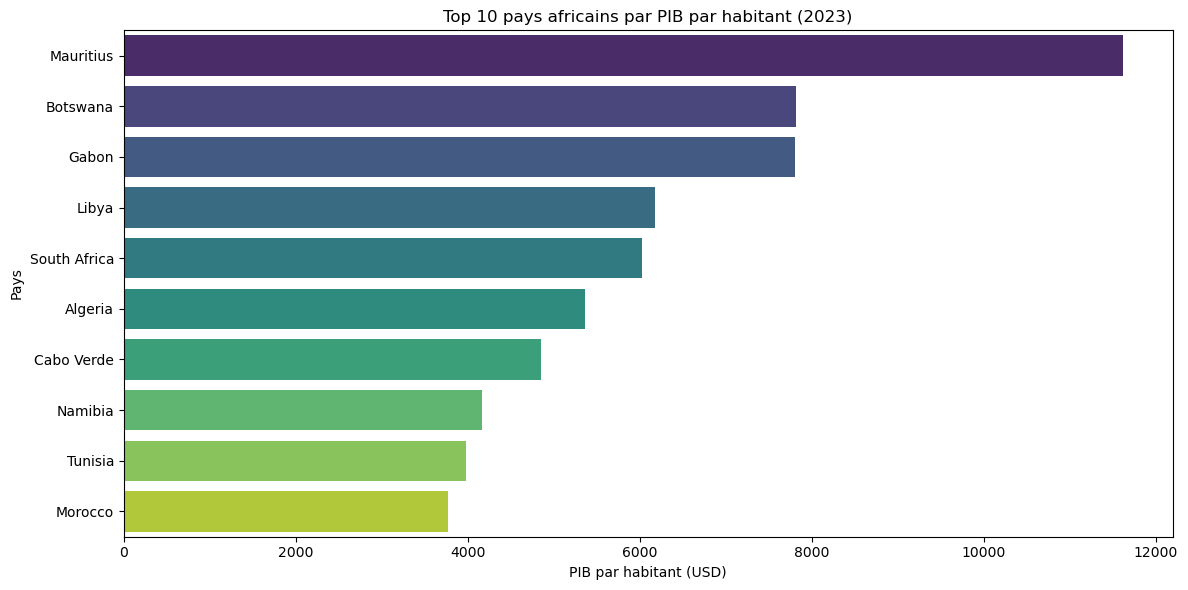

,country_name,GDP per Capita (Current USD)
2189,Mauritius,11613.044159
493,Botswana,7820.232404
1085,Gabon,7802.836596
1773,Libya,6172.812469
3437,South Africa,6022.542542
893,Algeria,5364.027950
701,Cabo Verde,4850.984158
2237,Namibia,4168.285211
3149,Tunisia,3977.695166
1933,Morocco,3771.446289


In [6]:
# Filtrer sur 2023
df_2023 = df_clean[df_clean['year'] == 2023]

# Top 10 PIB par habitant
top10 = df_2023.nlargest(10, 'GDP per Capita (Current USD)')

# Visualisation
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top10,
    x='GDP per Capita (Current USD)',
    y='country_name',
    palette='viridis'
)
plt.title('Top 10 pays africains par PIB par habitant (2023)')
plt.xlabel('PIB par habitant (USD)')
plt.ylabel('Pays')
plt.tight_layout()
plt.show()
top10[['country_name', 'GDP per Capita (Current USD)']]

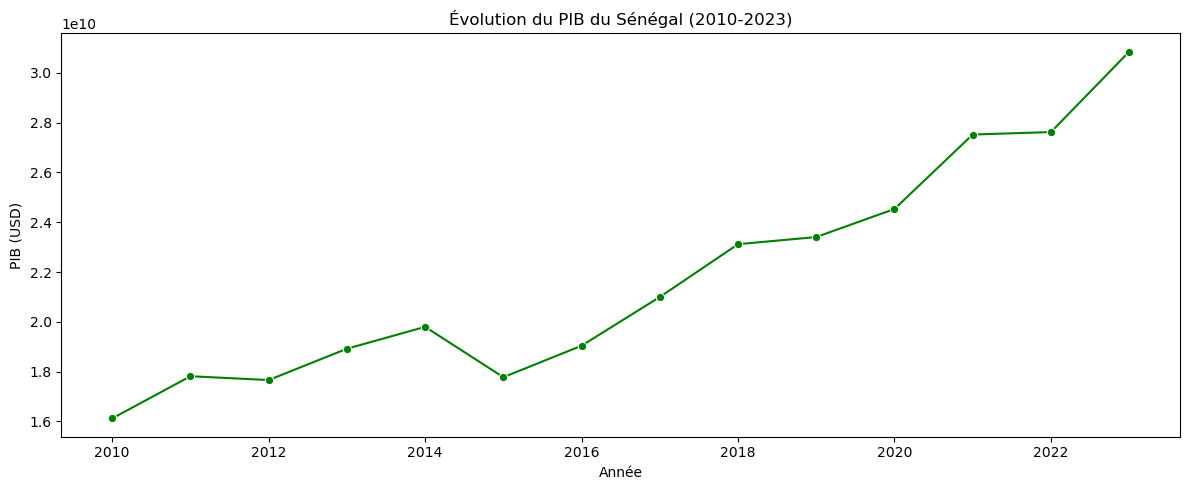

In [ ]:
# Filtrer sur le Sénégal
senegal = df_clean[df_clean['country_name'] == 'Senegal']
# Visualisation
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=senegal,
    x='year',
    y='GDP (Current USD)',
    marker='o',
    color='green'
)

plt.title("Évolution du PIB du Sénégal (2010-2023)")
plt.xlabel("Année")
plt.ylabel("PIB (USD)")
plt.tight_layout()
plt.show()

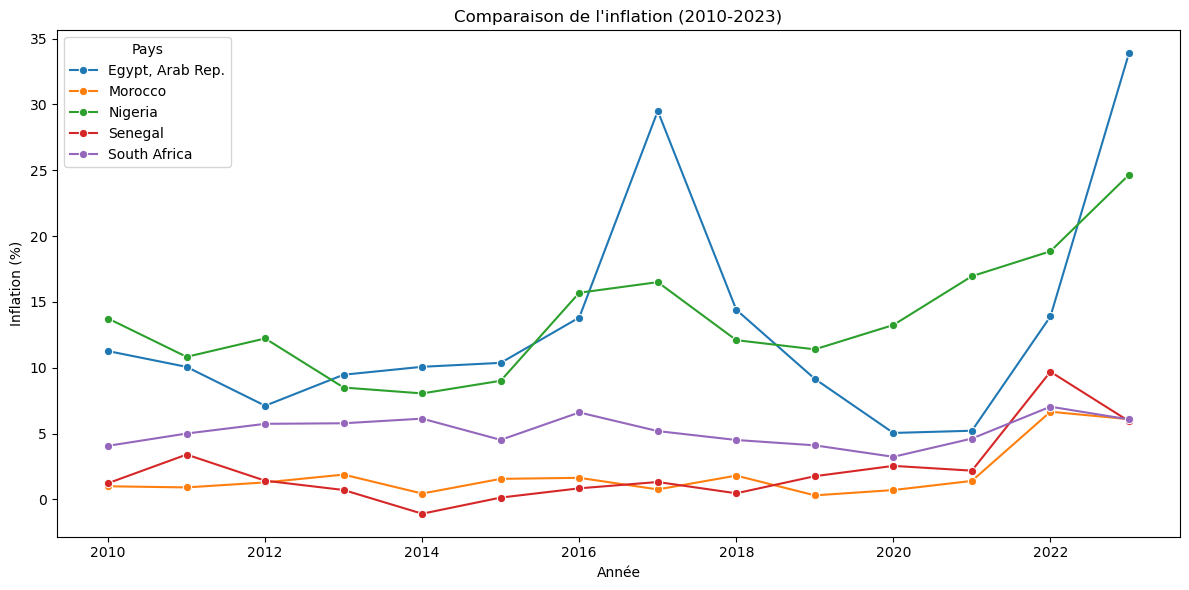

In [17]:
# Sélectionner 5 pays
df_pays = df_clean[df_clean['country_name'].isin(['Senegal', 'Nigeria', 'Egypt, Arab Rep.', 'South Africa', 'Morocco'])]
# Visualisation
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_pays,
    x='year',
    y='Inflation (CPI %)',
    hue='country_name',
    marker='o'
)
plt.title("Comparaison de l'inflation (2010-2023)")
plt.xlabel("Année")
plt.ylabel("Inflation (%)")
plt.legend(title='Pays')
plt.tight_layout()
plt.show()

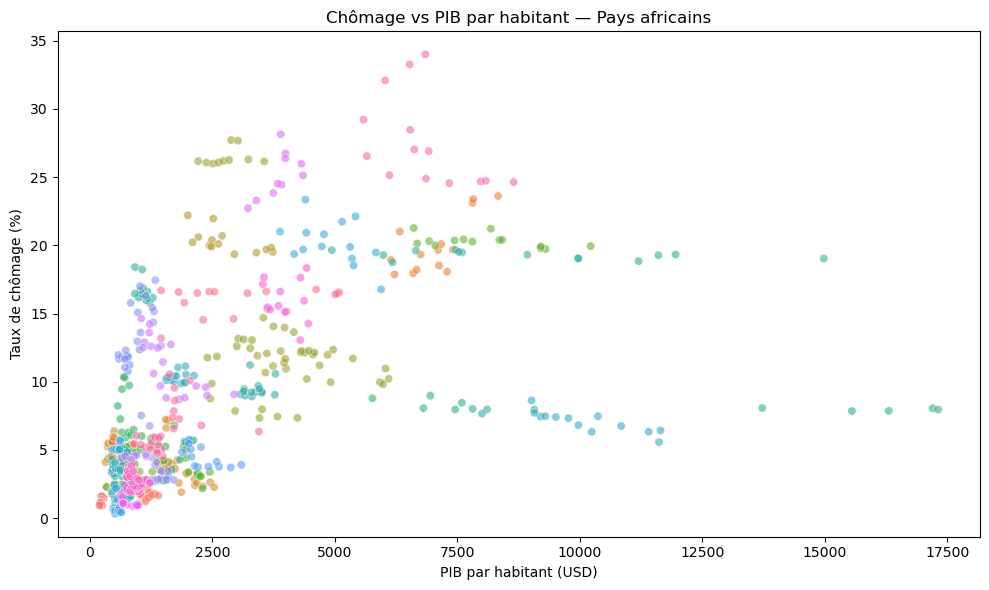

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x='GDP per Capita (Current USD)',
    y='Unemployment Rate (%)',
    hue='country_name',
    legend=False,
    alpha=0.6
)
plt.title("Chômage vs PIB par habitant — Pays africains")
plt.xlabel("PIB par habitant (USD)")
plt.ylabel("Taux de chômage (%)")
plt.tight_layout()
plt.show()

C:\Users\C_O_D\AppData\Local\Temp\ipykernel_17848\2098175374.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


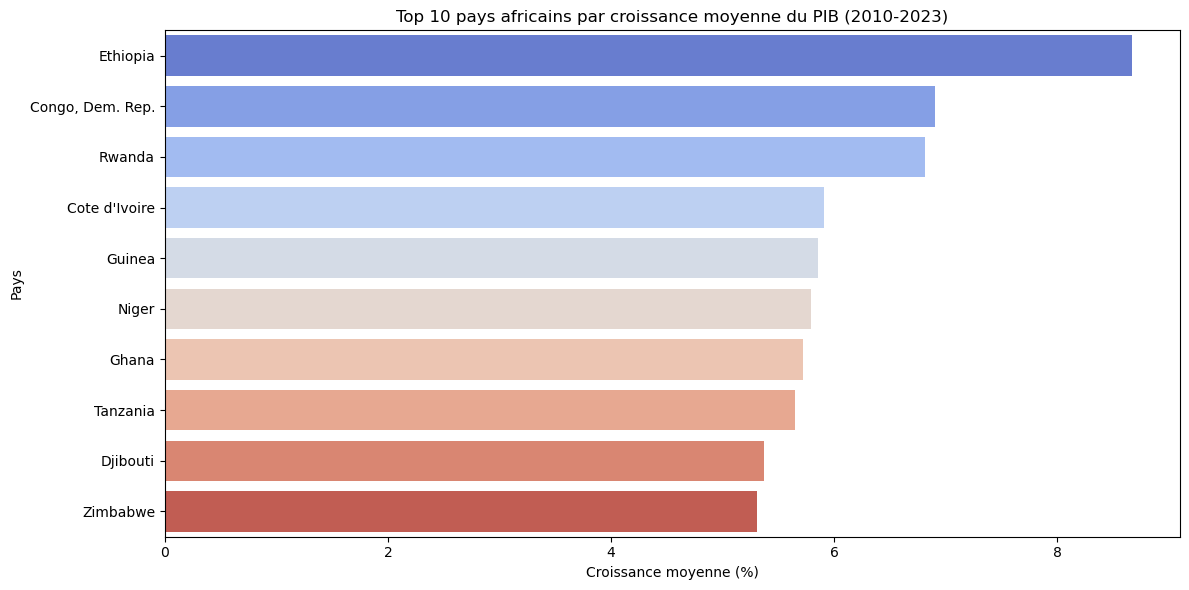

In [18]:
# Moyenne de croissance par pays sur toute la période
croissance = df_clean.groupby('country_name')['GDP Growth (% Annual)'].mean()
top10_croissance = croissance.nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top10_croissance,
    x='GDP Growth (% Annual)',
    y='country_name',
    palette='coolwarm'
)
plt.title("Top 10 pays africains par croissance moyenne du PIB (2010-2023)")
plt.xlabel("Croissance moyenne (%)")
plt.ylabel("Pays")
plt.tight_layout()
plt.show()